# 📊 End-to-End ML Pipeline: Telco Customer Churn Prediction

**Objective:** Build a reusable, production-ready ML pipeline using Scikit-learn Pipeline API

**Pipeline Steps:**
1. Data Loading & Exploration
2. Preprocessing (Scaling + Encoding)
3. Model Training (Logistic Regression & Random Forest)
4. Hyperparameter Tuning with GridSearchCV
5. Model Evaluation
6. Pipeline Export with joblib

## 1. 📦 Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import joblib
import os

warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score
)

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.size'] = 11

print('✅ All libraries imported successfully!')
print(f'   NumPy: {np.__version__} | Pandas: {pd.__version__}')

✅ All libraries imported successfully!
   NumPy: 2.4.4 | Pandas: 3.0.2


## 2. 📂 Data Loading & Exploration

In [2]:
# ── Telco Churn Dataset ──────────────────────────────────────────────────────
# Primary: load from local file if present, else fetch from GitHub mirror
LOCAL_PATH = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
REMOTE_URL = (
    'https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/'
    'master/data/Telco-Customer-Churn.csv'
)

if os.path.exists(LOCAL_PATH):
    df = pd.read_csv(LOCAL_PATH)
    print(f'✅ Loaded from local file: {LOCAL_PATH}')
else:
    df = pd.read_csv(REMOTE_URL)
    print(f'✅ Downloaded dataset from GitHub mirror')

print(f'\n📐 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Downloaded dataset from GitHub mirror

📐 Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset overview
print('=' * 55)
print('  DATASET OVERVIEW')
print('=' * 55)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print(f'  Memory  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print('=' * 55)
print('\n📋 Column dtypes:')
print(df.dtypes.to_string())
print(f'\n⚠️  Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

  DATASET OVERVIEW
  Rows    : 7,043
  Columns : 21
  Memory  : 6984.7 KB

📋 Column dtypes:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

⚠️  Missing values:
Series([], dtype: int64)


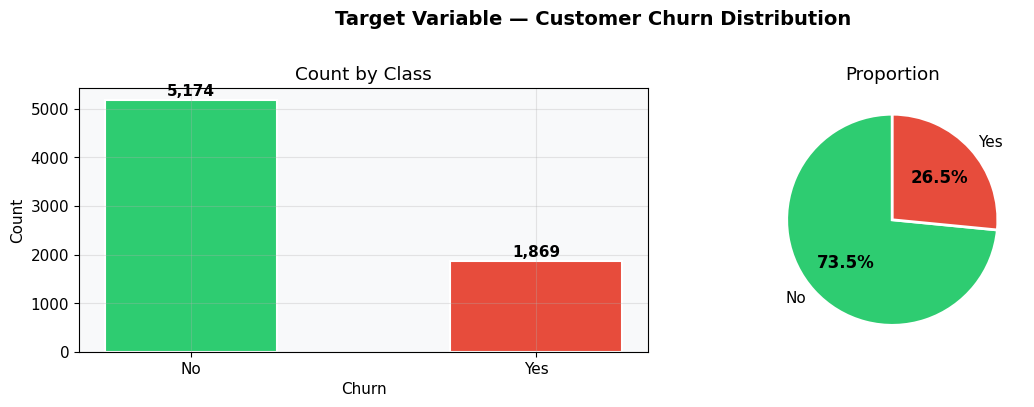

  No Churn : 5,174 (73.5%)
  Churn    : 1,869 (26.5%)


In [4]:
# Target distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable — Customer Churn Distribution', fontsize=14, fontweight='bold', y=1.01)

colors = ['#2ecc71', '#e74c3c']

# Bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Count by Class')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=churn_counts.index,
    autopct='%1.1f%%', colors=colors, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  No Churn : {churn_counts["No"]:,} ({churn_pct["No"]:.1f}%)')
print(f'  Churn    : {churn_counts["Yes"]:,} ({churn_pct["Yes"]:.1f}%)')

## 3. 🛠️ Data Preprocessing

In [5]:
# ── Fix known Telco dataset quirks ───────────────────────────────────────────
# 1. TotalCharges stored as string with spaces → coerce to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Drop customerID (identifier, not a feature)
df.drop(columns=['customerID'], inplace=True)

# 3. Encode target
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 4. Fill NaN introduced by coercion (< 0.2% of rows) with median
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# ── Feature split ─────────────────────────────────────────────────────────────
X = df.drop('Churn', axis=1)
y = df['Churn']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print('✅ Preprocessing complete')
print(f'   Numerical  features ({len(numerical_features)}): {numerical_features}')
print(f'   Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'\n   X shape: {X.shape} | y shape: {y.shape}')
print(f'   Churn rate: {y.mean():.2%}')

✅ Preprocessing complete
   Numerical  features (4): ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
   Categorical features (15): ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

   X shape: (7043, 19) | y shape: (7043,)
   Churn rate: 26.54%


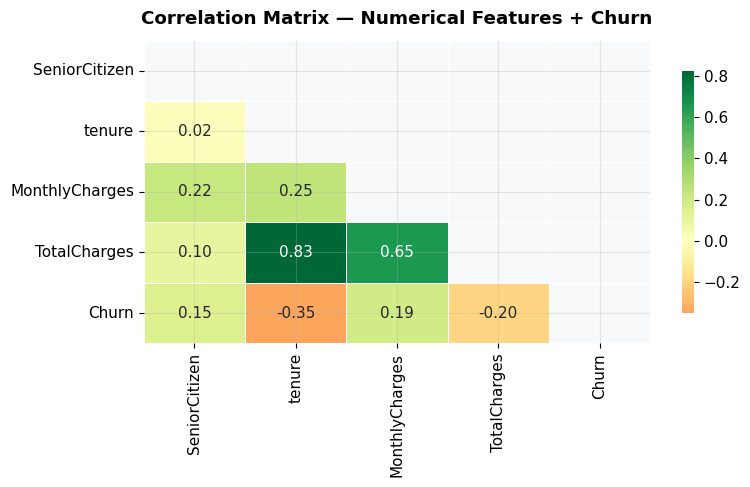

In [6]:
# ── Feature correlation heatmap (numerical) ───────────────────────────────────
corr = df[numerical_features + ['Churn']].corr()

plt.figure(figsize=(8, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Numerical Features + Churn', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('✅ Train / Test Split')
print(f'   Train : {X_train.shape[0]:,} samples  ({y_train.mean():.2%} churn)')
print(f'   Test  : {X_test.shape[0]:,} samples  ({y_test.mean():.2%} churn)')

✅ Train / Test Split
   Train : 5,634 samples  (26.54% churn)
   Test  : 1,409 samples  (26.54% churn)


## 4. 🔧 Building the Scikit-learn Pipeline

In [8]:
# ── Preprocessing sub-pipelines ───────────────────────────────────────────────
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ── ColumnTransformer: apply each transformer to the right columns ─────────────
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer,  numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

# ── Full pipelines (preprocessor + classifier) ─────────────────────────────────
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   LogisticRegression(max_iter=1000, random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier',   RandomForestClassifier(random_state=42, n_jobs=-1))
])

print('✅ Pipelines constructed')
print('\n🔄 Logistic Regression Pipeline steps:')
for name, step in lr_pipeline.steps:
    print(f'   [{name}] → {step.__class__.__name__}')

print('\n🌲 Random Forest Pipeline steps:')
for name, step in rf_pipeline.steps:
    print(f'   [{name}] → {step.__class__.__name__}')

✅ Pipelines constructed

🔄 Logistic Regression Pipeline steps:
   [preprocessor] → ColumnTransformer
   [classifier] → LogisticRegression

🌲 Random Forest Pipeline steps:
   [preprocessor] → ColumnTransformer
   [classifier] → RandomForestClassifier


## 5. 🔍 Hyperparameter Tuning with GridSearchCV

In [9]:
# ── Cross-validation strategy ─────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Logistic Regression grid ──────────────────────────────────────────────────
lr_param_grid = {
    'classifier__C':       [0.01, 0.1, 1, 10],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver':  ['liblinear', 'saga']
}

print('🔍 Running GridSearchCV — Logistic Regression ...')
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
lr_grid.fit(X_train, y_train)

print(f'   Best ROC-AUC : {lr_grid.best_score_:.4f}')
print(f'   Best params  : {lr_grid.best_params_}')

🔍 Running GridSearchCV — Logistic Regression ...


   Best ROC-AUC : 0.8463
   Best params  : {'classifier__C': 10, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}


In [10]:
# ── Random Forest grid ────────────────────────────────────────────────────────
rf_param_grid = {
    'classifier__n_estimators':      [100, 200],
    'classifier__max_depth':         [None, 10, 20],
    'classifier__min_samples_split': [2, 5],
    'classifier__max_features':      ['sqrt', 'log2']
}

print('🔍 Running GridSearchCV — Random Forest ...')
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=cv, scoring='roc_auc',
    n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)

print(f'   Best ROC-AUC : {rf_grid.best_score_:.4f}')
print(f'   Best params  : {rf_grid.best_params_}')

🔍 Running GridSearchCV — Random Forest ...


   Best ROC-AUC : 0.8435
   Best params  : {'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}


## 6. 📈 Model Evaluation

In [11]:
def evaluate_model(name, model, X_test, y_test):
    """Return a dict of evaluation metrics for a fitted model."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba),
        '_y_pred':   y_pred,
        '_y_proba':  y_proba
    }

lr_metrics = evaluate_model('Logistic Regression', lr_grid.best_estimator_, X_test, y_test)
rf_metrics = evaluate_model('Random Forest',       rf_grid.best_estimator_, X_test, y_test)

# Clean summary table
metric_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df = pd.DataFrame([lr_metrics, rf_metrics])[metric_cols]
results_df.set_index('Model', inplace=True)
results_df = results_df.map(lambda v: f'{v:.4f}')

print('\n📊 Test-Set Performance Comparison')
print('=' * 62)
print(results_df.to_string())
print('=' * 62)


📊 Test-Set Performance Comparison
                    Accuracy Precision  Recall F1 Score ROC-AUC
Model                                                          
Logistic Regression   0.8048    0.6552  0.5588   0.6032  0.8411
Random Forest         0.8020    0.6655  0.5107   0.5779  0.8384


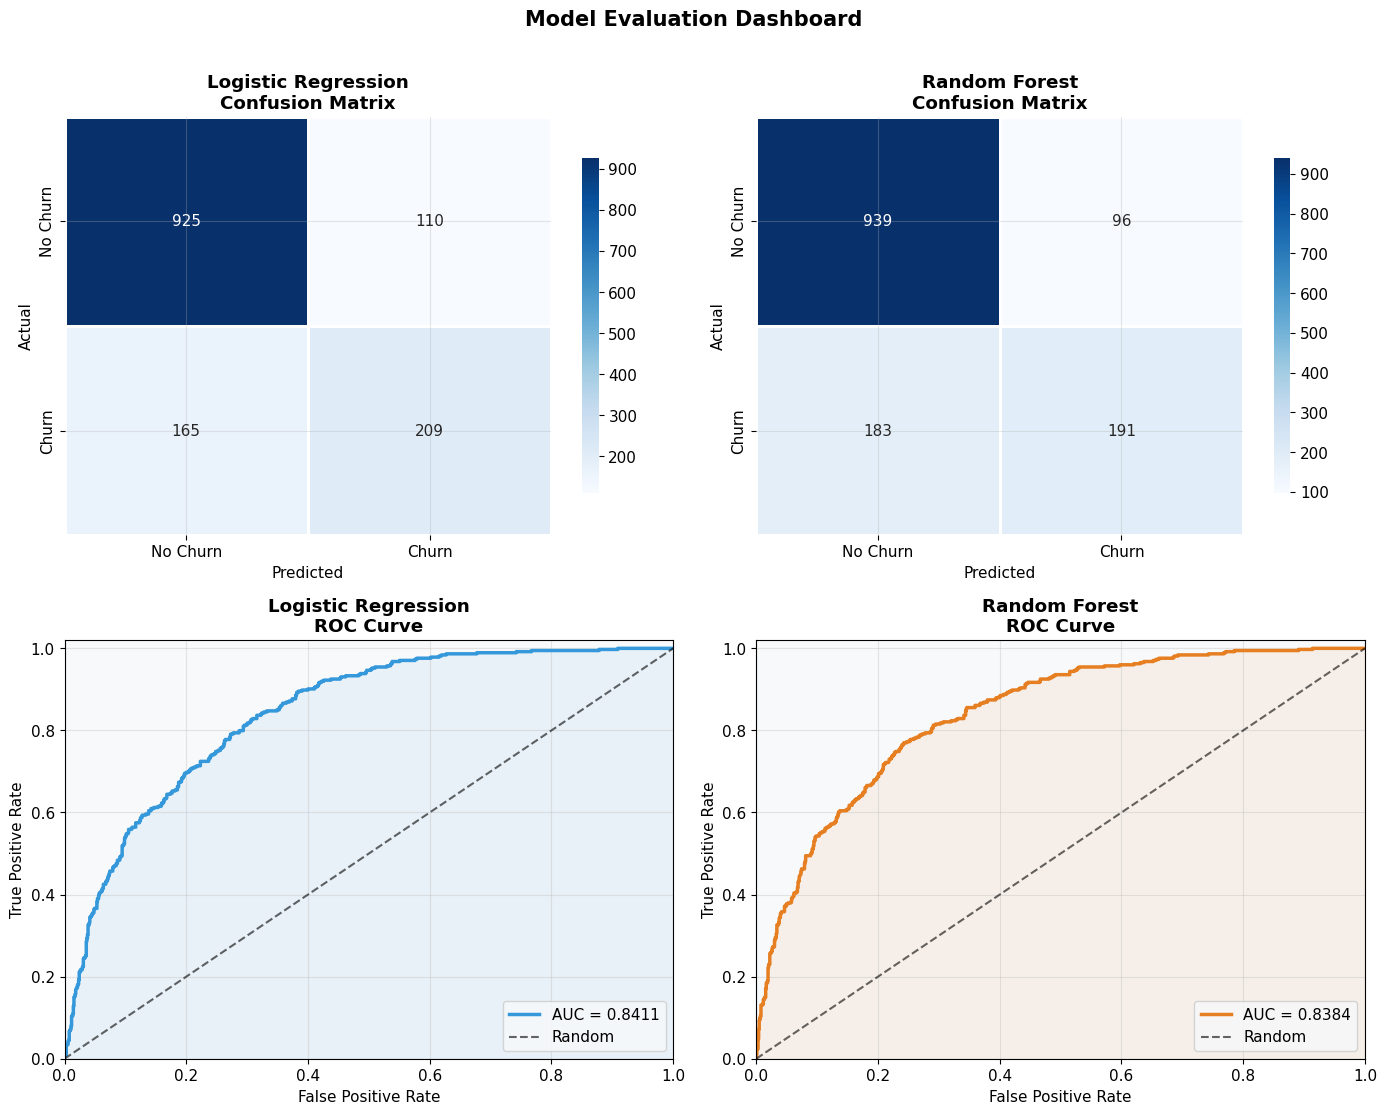

In [12]:
# ── Visual evaluation: Confusion Matrices + ROC Curves ───────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold', y=1.01)

models_info = [
    ('Logistic Regression', lr_metrics, '#3498db'),
    ('Random Forest',       rf_metrics, '#e67e22')
]

for col, (name, metrics, color) in enumerate(models_info):
    # ── Confusion Matrix ──────────────────────────────────────────────────────
    ax_cm = axes[0][col]
    cm = confusion_matrix(y_test, metrics['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                linewidths=1, linecolor='white', ax=ax_cm,
                cbar_kws={'shrink': 0.8})
    ax_cm.set_title(f'{name}\nConfusion Matrix', fontweight='bold')
    ax_cm.set_xlabel('Predicted')
    ax_cm.set_ylabel('Actual')

    # ── ROC Curve ─────────────────────────────────────────────────────────────
    ax_roc = axes[1][col]
    fpr, tpr, _ = roc_curve(y_test, metrics['_y_proba'])
    auc_val = metrics['ROC-AUC']
    ax_roc.plot(fpr, tpr, color=color, lw=2.5,
                label=f'AUC = {auc_val:.4f}')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6, label='Random')
    ax_roc.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.set_title(f'{name}\nROC Curve', fontweight='bold')
    ax_roc.legend(loc='lower right', fontsize=11)
    ax_roc.set_xlim([0, 1])
    ax_roc.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

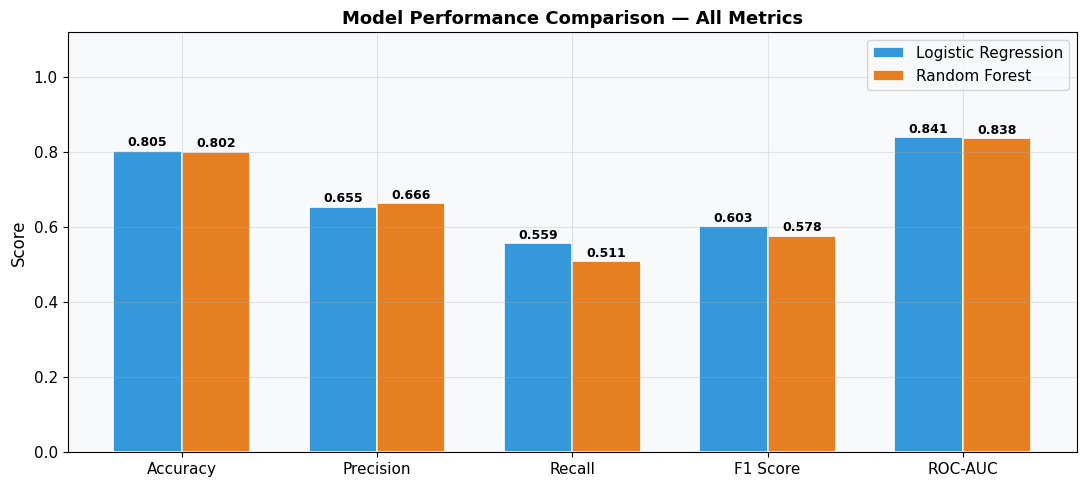

In [13]:
# ── Metrics Bar Chart comparison ──────────────────────────────────────────────
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
lr_vals = [lr_metrics[m] for m in metric_names]
rf_vals = [rf_metrics[m] for m in metric_names]

x = np.arange(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, lr_vals, width, label='Logistic Regression',
               color='#3498db', edgecolor='white', linewidth=1.2)
bars2 = ax.bar(x + width/2, rf_vals, width, label='Random Forest',
               color='#e67e22', edgecolor='white', linewidth=1.2)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Detailed classification reports ──────────────────────────────────────────
for name, metrics in [('Logistic Regression', lr_metrics), ('Random Forest', rf_metrics)]:
    print(f'\n{"="*55}')
    print(f'  Classification Report — {name}')
    print(f'{"="*55}')
    print(classification_report(
        y_test, metrics['_y_pred'],
        target_names=['No Churn', 'Churn']
    ))


  Classification Report — Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


  Classification Report — Random Forest
              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



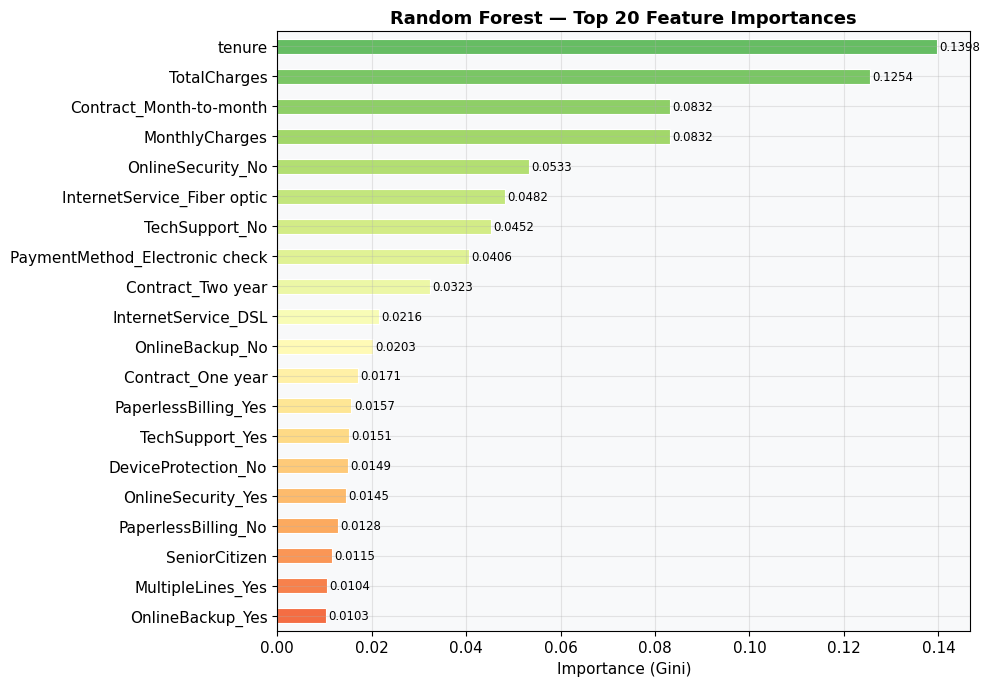

In [15]:
# ── Feature importance (Random Forest) ───────────────────────────────────────
best_rf = rf_grid.best_estimator_
rf_clf  = best_rf.named_steps['classifier']

# Recover feature names after OneHotEncoding
ohe_cols = (best_rf.named_steps['preprocessor']
                   .named_transformers_['cat']
                   .named_steps['onehot']
                   .get_feature_names_out(categorical_features).tolist())
feature_names = numerical_features + ohe_cols

importances = pd.Series(rf_clf.feature_importances_, index=feature_names)
top20 = importances.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top20)))
top20.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white', linewidth=0.8)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Gini)', fontsize=11)
ax.set_ylabel('')
for i, (val, name) in enumerate(zip(top20.values, top20.index)):
    ax.text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('feature_importances.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 💾 Export Pipelines with joblib

In [16]:
os.makedirs('saved_models', exist_ok=True)

# Best model selection
best_model_name, best_pipeline = (
    ('Random Forest',       rf_grid.best_estimator_)
    if rf_metrics['ROC-AUC'] >= lr_metrics['ROC-AUC']
    else ('Logistic Regression', lr_grid.best_estimator_)
)

# Export both + winner
joblib.dump(lr_grid.best_estimator_, 'saved_models/logistic_regression_pipeline.joblib')
joblib.dump(rf_grid.best_estimator_, 'saved_models/random_forest_pipeline.joblib')
joblib.dump(best_pipeline,           'saved_models/best_pipeline.joblib')

# Verify file sizes
for fname in os.listdir('saved_models'):
    fpath = f'saved_models/{fname}'
    size_kb = os.path.getsize(fpath) / 1024
    print(f'   ✅  {fname:<45} {size_kb:>7.1f} KB')

print(f'\n🏆 Best model: {best_model_name} (ROC-AUC: {max(lr_metrics["ROC-AUC"], rf_metrics["ROC-AUC"]):.4f})')

   ✅  random_forest_pipeline.joblib                 10897.8 KB
   ✅  best_pipeline.joblib                              8.3 KB
   ✅  logistic_regression_pipeline.joblib               8.3 KB

🏆 Best model: Logistic Regression (ROC-AUC: 0.8411)


## 8. 🔁 Pipeline Reload & Prediction Demo

In [17]:
# ── Reload and verify ─────────────────────────────────────────────────────────
loaded_pipeline = joblib.load('saved_models/best_pipeline.joblib')

# Predict on a sample of 5 unseen rows
sample = X_test.sample(5, random_state=7)
sample_true = y_test.loc[sample.index]

sample_pred  = loaded_pipeline.predict(sample)
sample_proba = loaded_pipeline.predict_proba(sample)[:, 1]

demo = sample[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
demo['True_Churn']     = sample_true.values
demo['Predicted_Churn'] = sample_pred
demo['Churn_Prob']      = sample_proba.round(4)

print('🔄 Pipeline reloaded from disk — prediction demo:')
print('=' * 62)
print(demo.to_string(index=False))
print('\n✅ Pipeline is fully functional and production-ready!')

🔄 Pipeline reloaded from disk — prediction demo:
 tenure  MonthlyCharges  TotalCharges  True_Churn  Predicted_Churn  Churn_Prob
      1           71.00         71.00           1                1      0.6478
     42           63.70       2763.35           0                0      0.0272
      4           90.65        367.95           0                1      0.6124
     12           79.55        958.25           0                1      0.5068
     25           54.20       1423.15           0                0      0.2172

✅ Pipeline is fully functional and production-ready!


## 9. 📋 Summary

In [18]:
print('=' * 62)
print('  END-TO-END ML PIPELINE — FINAL SUMMARY')
print('=' * 62)
print(f'  Dataset          : Telco Customer Churn')
print(f'  Total samples    : {len(df):,}')
print(f'  Churn rate       : {y.mean():.2%}')
print(f'  Features used    : {X.shape[1]} ({len(numerical_features)} num, {len(categorical_features)} cat)')
print()
print('  ┌──────────────────────┬────────┬────────┬────────┐')
print('  │ Model                │ Acc.   │ F1     │ AUC    │')
print('  ├──────────────────────┼────────┼────────┼────────┤')
print(f'  │ Logistic Regression  │ {lr_metrics["Accuracy"]:.4f} │ {lr_metrics["F1 Score"]:.4f} │ {lr_metrics["ROC-AUC"]:.4f} │')
print(f'  │ Random Forest        │ {rf_metrics["Accuracy"]:.4f} │ {rf_metrics["F1 Score"]:.4f} │ {rf_metrics["ROC-AUC"]:.4f} │')
print('  └──────────────────────┴────────┴────────┴────────┘')
print()
print(f'  🏆 Best Model : {best_model_name}')
print(f'  💾 Exported   : saved_models/best_pipeline.joblib')
print('=' * 62)

  END-TO-END ML PIPELINE — FINAL SUMMARY
  Dataset          : Telco Customer Churn
  Total samples    : 7,043
  Churn rate       : 26.54%
  Features used    : 19 (4 num, 15 cat)

  ┌──────────────────────┬────────┬────────┬────────┐
  │ Model                │ Acc.   │ F1     │ AUC    │
  ├──────────────────────┼────────┼────────┼────────┤
  │ Logistic Regression  │ 0.8048 │ 0.6032 │ 0.8411 │
  │ Random Forest        │ 0.8020 │ 0.5779 │ 0.8384 │
  └──────────────────────┴────────┴────────┴────────┘

  🏆 Best Model : Logistic Regression
  💾 Exported   : saved_models/best_pipeline.joblib
